<a href="https://colab.research.google.com/github/sreuter1/transfer_learning/blob/main/Final_SigLIP_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Needed Libraries - Routing to Proper Device

In [ ]:
!pip install -q transformers torch

import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split, Dataset
from transformers import SiglipModel, SiglipConfig
from transformers import SiglipImageProcessor
import torch.nn.functional as F
from torchvision import transforms

from PIL import Image
import requests

print("torch:", torch.__version__)
device = "cuda"  # Change device in the runtime settings - to GPU T4
print(torch.cuda.is_available())
print("device:", device)

def set_seed(seed: int = 42):                                                                       # Here for reproducability
    """Make results as reproducible as possible across runs."""
    # os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)                                                                                        # Here for reproducability


torch: 2.11.0+cu128
True
device: cuda


Importing From Kaggle API - Get Kaggle key first - Already Downloaded

In [ ]:
!export KAGGLE_API_TOKEN=KGAT_6e0db17c19cd9ec6f55621b971c1014d

!mkdir -p ~/.kaggle && echo KGAT_6e0db17c19cd9ec6f55621b971c1014d > ~/.kaggle/access_token && chmod 666 ~/.kaggle/access_token

!kaggle competitions list

!export KAGGLE_API_TOKEN=KGAT_d77bc5e53c781f271763950cf13abd1c

!mkdir -p ~/.kaggle && echo KGAT_d77bc5e53c781f271763950cf13abd1c > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [ ]:
# Code that kaggle said to run to get access to the competition files
import kagglehub

# Download latest version
path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/ucsc-cse-144-spring-2026-final-project


Data Pipeline - Dataset and DataLoader

In [ ]:
from transformers import SiglipImageProcessor
from torchvision.transforms import v2

batch_size = 32
num_workers = 0
val_p = 0.2

# pull SigLIP's correct mean/std instead of hardcoded ImageNet stats
processor = SiglipImageProcessor.from_pretrained("google/siglip-base-patch16-224")
mean = processor.image_mean
std  = processor.image_std

train_tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize((224, 224)),
    v2.RandomResizedCrop(224, scale=(0.6, 1.0)),
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean, std)
])

test_tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean, std)
])

train_path = path + '/train'
test_path  = path + '/test'

class UnlabeledDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root      = root
        self.transform = transform
        self.images    = sorted(os.listdir(root))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.images[idx])
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.images[idx]

# IMPORTANT: create base datasets with their respective transforms BEFORE splitting
# random_split doesn't let you set different transforms per subset easily otherwise
train_base = datasets.ImageFolder(root=train_path, transform=train_tf)
val_base   = datasets.ImageFolder(root=train_path, transform=test_tf)
test_set   = UnlabeledDataset(root=test_path, transform=test_tf)

train_size = int((1 - val_p) * len(train_base))
val_size   = len(train_base) - train_size

# split using the same indices so train gets augmentation, val gets clean transforms
indices = torch.randperm(len(train_base)).tolist()
train_set = torch.utils.data.Subset(train_base, indices[:train_size])
val_set   = torch.utils.data.Subset(val_base,   indices[train_size:])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("train/val/test:", len(train_set), len(val_set), len(test_set))

train/val/test: 863 216 1036


Defining the Siglip model

In [ ]:
class LoRALinear(nn.Module):
  def __init__(self, linear: nn.Linear, rank=16, alpha=1):
    super().__init__()
    self.frozen_linear = linear
    self.rank = rank
    self.scale = alpha/rank

    in_f = linear.in_features
    out_f = linear.out_features

    self.lora_A = nn.Parameter(torch.empty(rank, in_f))
    self.lora_B = nn.Parameter(torch.zeros(out_f, rank))

    nn.init.kaiming_uniform_(self.lora_A, a=5**0.5)

    for p in self.frozen_linear.parameters():
      p.requires_grad = False

  @property
  def weight(self):
    return self.frozen_linear.weight

  @property
  def bias(self):
    return self.frozen_linear.bias

  @property
  def in_features(self):
    return self.frozen_linear.in_features

  @property
  def out_features(self):
    return self.frozen_linear.out_features

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    frozen_out = self.frozen_linear(x)
    lora_out = (x @ self.lora_A.T) @ self.lora_B.T
    return frozen_out + lora_out * self.scale

def add_lora_siglip(model: nn.Module, rank=4, alpha=4.0):
  injected = 0
  #targeting the vision encoder specifically
  for name, module in model.vision_model.named_modules():
    if hasattr(module, 'out_proj') and isinstance(module.out_proj, nn.Linear):
      module.out_proj = LoRALinear(module.out_proj, rank=rank, alpha=alpha)
      injected += 1
  print(f"Injected LoRA into {injected} attention output projections")
  return model


class SigLIPClassifier(nn.Module):
  def __init__(self, num_classes=100, rank=4, alpha=4.0):
    super().__init__()
    self.backbone = SiglipModel.from_pretrained("google/siglip-base-patch16-224")

    #freeze everything
    for param in self.backbone.parameters():
      param.requires_grad = False

    #injecting low rank adaptation
    self.backbone = add_lora_siglip(self.backbone, rank=rank, alpha=alpha)

    #siglip base hidden size si 768, same as ViT-B
    hidden_size = self.backbone.config.vision_config.hidden_size

    self.head = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(hidden_size, num_classes)
    )


  def forward(self, x: torch.Tensor):
        # SigLIP vision encoder returns last_hidden_state; use CLS token (index 0)
        vision_outputs = self.backbone.vision_model(pixel_values=x)
        cls_token = vision_outputs.last_hidden_state[:, 0, :]  # (B, hidden_size)
        return self.head(cls_token)

model = SigLIPClassifier(num_classes = 100, rank=4, alpha=4.0).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")



Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Injected LoRA into 13 attention output projections
Trainable: 156,772 / Total: 203,312,742


Training Function

In [ ]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)          # ADDED LABEL SMOOTHING
#optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01) --> not going to use Adagrad; uncommon for ViT fine-tuning and can hurt convergence
encoder_layers = model.backbone.vision_model.encoder.layers

optimizer = torch.optim.AdamW([
    {
        "params": encoder_layers[:-2].parameters(),
        "lr": 1e-5,
        "weight_decay": 0.01
    },
    {
        "params": encoder_layers[-2:].parameters(),
        "lr": 5e-5,
        "weight_decay": 0.01
    },
    {
        "params": model.head.parameters(),
        "lr": 1e-4,
        "weight_decay": 0.01
    }
])

for p in encoder_layers[:-4].parameters():
    p.requires_grad = False

epochs = 30             #changed from 10 -> 30
steps_per_epoch = len(train_loader)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    pct_start=0.1,         #lowered from 20% --> 10%
    anneal_strategy="cos"                                     # ADDED COSINE ANNEALING
)

def mixup_batch(x, y, num_classes=100, alpha=0.4):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)

    mixed_x = lam * x + (1 - lam) * x[idx]

    # integers go in, soft float labels come out
    y_a = F.one_hot(y, num_classes).float()
    y_b = F.one_hot(y[idx], num_classes).float()
    mixed_y = lam * y_a + (1 - lam) * y_b      # e.g. [0.7, 0, 0.3, 0, ...]

    return mixed_x, mixed_y, y

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # - Set model to training mode
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # - Loop through batches in the loader
    for batch, (X,y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        X, y_soft, y_hard = mixup_batch(X, y)
        optimizer.zero_grad()           #   * Zero gradients
        prediction = model(X)           #   * Forward pass
        loss = criterion(prediction,y_soft)  #   * Compute loss
        loss.backward()                 #   * Backward pass
        optimizer.step()                #   * Optimizer step
        scheduler.step()

        total_loss += loss.item()
        predicted = prediction.argmax(dim=1)
        correct+= (predicted == y_hard).sum().item()
        total += y.size(0)
    avg_loss = total_loss/len(loader)
    accuracy = correct/total

    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

Validation Function

In [ ]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""

    model.eval()                                 # - Set model to evaluation mode

    total_loss = 0.0                             # - Creating variables for loss and accuracy calculations
    correct = 0
    total = 0

    with torch.no_grad():
      for X, y in loader:
          X, y = X.to(device), y.to(device)        # - Loop through batches without computing gradients
          prediction = model(X)
          loss = criterion(prediction,y)
          total_loss += loss.item()
          predicted = prediction.argmax(dim=1)
          correct+= (predicted == y).sum().item()
          total += y.size(0)
      avg_loss = total_loss/len(loader)            # computing loss and accuracy
      accuracy = correct/total

    return avg_loss, accuracy

Training Loop

In [ ]:
# Q3.3: Training loop with checkpointing
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_transfer.ViT.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# - Loop through epochs
for i in range(epochs):
    # - Each epoch: train, validate, log metrics
    train_loss, train_accuracy = train_one_epoch(model, train_loader)
    valid_loss, valid_accuracy = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(valid_loss)
    history["val_acc"].append(valid_accuracy)

    # - Track best validation accuracy and save checkpoint when improved
    if (valid_accuracy > best_val_acc):
        best_epoch = i
        best_val_acc = valid_accuracy
        torch.save(
            {"model_state_dict": model.state_dict(), "epoch": i},
            ckpt_path
        )

    # - Print training and validation metrics each epoch
    print("train_loss:", train_loss, "train_accuracy:", train_accuracy)
    print("valid_loss:", valid_loss, "valid_accuracy:", valid_accuracy)


print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

train_loss: 5.596683873070611 train_accuracy: 0.009269988412514484
valid_loss: 5.053365775517055 valid_accuracy: 0.013888888888888888
train_loss: 5.063627649236609 train_accuracy: 0.026651216685979143
valid_loss: 4.361383506229946 valid_accuracy: 0.05555555555555555
train_loss: 4.368838557490596 train_accuracy: 0.07647740440324449
valid_loss: 3.9563540390559604 valid_accuracy: 0.06944444444444445
train_loss: 4.009036399700023 train_accuracy: 0.08458864426419467
valid_loss: 3.6936631202697754 valid_accuracy: 0.1574074074074074
train_loss: 3.8145117494795056 train_accuracy: 0.0984936268829664
valid_loss: 3.4121792997632707 valid_accuracy: 0.18981481481481483
train_loss: 3.631257171984072 train_accuracy: 0.15179606025492468
valid_loss: 3.301089252744402 valid_accuracy: 0.18981481481481483
train_loss: 3.4274740660632097 train_accuracy: 0.13441483198146004
valid_loss: 3.028672456741333 valid_accuracy: 0.25
train_loss: 3.1960137596836797 train_accuracy: 0.2085747392815759
valid_loss: 2.81772

# Implementing Phase Training

In [ ]:
# Redeclaring variables
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
patience = 8

In [ ]:
phases = [
    {
        "name": "head_only",
        "epochs": 15,
        "unfreeze": [],
        "lrs": {"head": 1e-3},
        "dropout": 0.3,
    },
    {
        "name": "top_layers",
        "epochs": 15,
        "unfreeze": [-1, -2],
        "lrs": {"layer4": 1e-4, "head": 1e-3},
        "dropout": 0.4,
    },
    {
        "name": "full_finetune",
        "epochs": 30,
        "unfreeze": [-3, -4, -5, -6],
        "lrs": {"backbone": 1e-5, "head": 1e-4},
        "dropout": 0.5,
    },
]

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
encoder_layers = list(model.backbone.vision_model.encoder.layers)

for phase in phases:

    epochs_without_improvement = 0

    # 1. Unfreeze layers
    encoder_layers = list(model.backbone.vision_model.encoder.layers)
    for layer_idx in phase["unfreeze"]:
        for param in encoder_layers[layer_idx].parameters():
            param.requires_grad = True

    # 2. Update dropout
    for module in model.head.modules():
      if isinstance(module, nn.Dropout):
          module.p = phase["dropout"]

    # 3. Build optimizer fresh each phase
    param_groups = [
        {"params": getattr(model, k, model.backbone).parameters(), "lr": v, "weight_decay": 0.001 if k != "head" else 0.01}
        for k, v in phase["lrs"].items()
    ]
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=max(phase["lrs"].values()),
        weight_decay=0.01
    ) if len(phase["lrs"]) == 1 else torch.optim.AdamW(param_groups)

    # 4. Build scheduler fresh each phase
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[v for v in phase["lrs"].values()],
        steps_per_epoch=steps_per_epoch,
        epochs=phase["epochs"],
        pct_start=0.1,
        anneal_strategy="cos"
    )

    # 5. Train
    best_val_acc = 0.0
    best_epoch = -1
    ckpt_path = "./checkpoints/best_transfer.ViT.pt"
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    # - Loop through epochs
    for epoch in range(phase["epochs"]):
        # - Each epoch: train, validate, log metrics
        train_loss, train_accuracy = train_one_epoch(model, train_loader)
        valid_loss, valid_accuracy = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_accuracy)
        history["val_loss"].append(valid_loss)
        history["val_acc"].append(valid_accuracy)

        # - Track best validation accuracy and save checkpoint when improved
        if (valid_accuracy > best_val_acc):
            best_epoch = epoch
            best_val_acc = valid_accuracy
            torch.save(
                {"model_state_dict": model.state_dict(), "epoch": epoch},
                ckpt_path
            )

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping phase "
                f"{phase['name']} after {epoch+1} epochs"
            )
            break

        # - Print training and validation metrics each epoch
        print("train_loss:", train_loss, "train_accuracy:", train_accuracy)
        print("valid_loss:", valid_loss, "valid_accuracy:", valid_accuracy)


    print("Best val acc:", best_val_acc, "at epoch", best_epoch)
    print("Saved to:", ckpt_path)

train_loss: 1.9422419203652277 train_accuracy: 0.43337195828505215
valid_loss: 1.7612934964043754 valid_accuracy: 0.6759259259259259
train_loss: 2.0693668303666293 train_accuracy: 0.3302433371958285
valid_loss: 1.8836205857140678 valid_accuracy: 0.6388888888888888
train_loss: 2.091191945252595 train_accuracy: 0.4797219003476246
valid_loss: 1.7913953747068132 valid_accuracy: 0.6712962962962963
train_loss: 2.1821697420544095 train_accuracy: 0.40903823870220163
valid_loss: 1.821747864995684 valid_accuracy: 0.6574074074074074
train_loss: 2.244321174091763 train_accuracy: 0.38122827346465815
valid_loss: 1.843967114176069 valid_accuracy: 0.6527777777777778
train_loss: 2.16831013891432 train_accuracy: 0.4298957126303592
valid_loss: 1.7357216903141566 valid_accuracy: 0.6527777777777778
train_loss: 2.0074548853768244 train_accuracy: 0.40324449594438005
valid_loss: 1.7316640956061227 valid_accuracy: 0.6759259259259259
train_loss: 2.3152173404340393 train_accuracy: 0.38933951332560834
valid_loss:

Curves

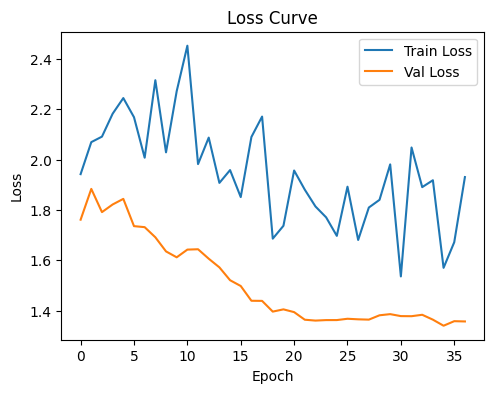

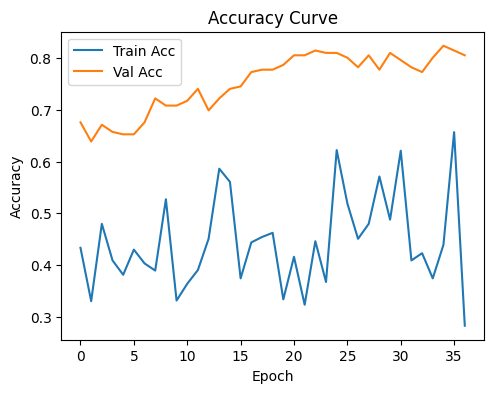

In [ ]:
# Loss ------------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy --------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'],   label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ========== YOUR CODE ENDS HERE ============

Testing

In [ ]:
# Q4: Test evaluation

checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Evaluate the best model state from the checkpoint
test_loss, test_acc = evaluate(model, val_loader)

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Test loss: 1.3402 | Test acc: 0.8241


In [ ]:
import pandas as pd

def load_model(ckpt_path, num_classes, device):
    model = SigLIPClassifier(num_classes = 100, rank=4, alpha=4.0).to(device)
    model.head[1] = nn.Linear(model.head[1].in_features, num_classes)

    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    model.to(device)
    model.eval()
    return model

# Load single model
model = load_model(ckpt_path, 100, device)

# Run inference
all_paths = []
all_probs = []

with torch.no_grad():
    for images, paths in test_loader:
        all_paths.extend(paths)
        images = images.to(device)
        probs = torch.softmax(model(images), dim=1)
        all_probs.append(probs.cpu().numpy())

# Take argmax of single model's predictions
all_probs = np.concatenate(all_probs, axis=0)  # (n_samples, n_classes)
predictions = all_probs.argmax(axis=1)          # (n_samples,)

# Map to class names
idx_to_class = {v: k for k, v in train_base.class_to_idx.items()}
pred_labels = [idx_to_class[p] for p in predictions]

# Save CSV
os.makedirs("./submissions", exist_ok=True)
filenames = [os.path.basename(p) for p in all_paths]
df = pd.DataFrame({"ID": filenames, "# Label": pred_labels})

# Sort numerically by extracting the number from the filename
df["sort_key"] = df["ID"].str.extract(r"(\d+)").astype(int)
df = df.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)

df.to_csv("./submissions/predictions.csv", index=False)
print(df.head())

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Injected LoRA into 13 attention output projections
      ID # Label
0  0.jpg      62
1  1.jpg      43
2  2.jpg      38
3  3.jpg      51
4  4.jpg      42


In [ ]:
from google.colab import files

files.download("./submissions/predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(ckpt_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>